In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight



## Créer les générateurs de données


In [2]:
# Définir les chemins des ensembles
train_dir = 'C:\\Users\\hp\\Desktop\\Innovation et plannification\\Data\\Final_DataSet'
val_dir = 'C:\\Users\\hp\\Desktop\\Innovation et plannification\\Data\\Final_DataSet_Val'
test_dir = 'C:\\Users\\hp\\Desktop\\Innovation et plannification\\Data\\Final_DataSet_Test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des données
train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(128, 128), batch_size=32, class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir, target_size=(128, 128), batch_size=32, class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir, target_size=(128, 128), batch_size=32, class_mode='categorical', shuffle=False
)



Found 29989 images belonging to 6 classes.
Found 642 images belonging to 6 classes.
Found 642 images belonging to 6 classes.


## Construire le modele cnn

In [3]:

# Chargement du modèle MobileNet (pré-entraîné)
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Geler les couches de base
for layer in base_model.layers[-50:]:  # Déverrouiller les 50 dernières couches
    layer.trainable = True

# Ajout des couches personnalisées
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)  # Normalisation des données
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)  # Couche dense avec régularisation L2
x = Dropout(0.5)(x)  # Dropout pour éviter l'overfitting
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)  # 6 classes à prédire

# Création du modèle
model = Model(inputs=base_model.input, outputs=output)


# Compiler le modéle

In [4]:


# Compilation du modèle avec un taux d'apprentissage réduit
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)  # Taux d'apprentissage très bas
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks pour éviter l'overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7)

# Entrainement du modéle

In [5]:


class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(train_data.labels), y=train_data.labels
)
class_weights_dict = dict(enumerate(class_weights))
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.95  # Réduit le taux d'apprentissage de 5% après chaque époque

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)

model.fit(train_data, validation_data=val_data, epochs=20, callbacks=[early_stopping, reduce_lr, lr_scheduler], verbose=1)



Epoch 1/20


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 1277s 1s/step - accuracy: 0.3507 - loss: 7.5823 - val_accuracy: 0.7072 - val_loss: 5.8257 - learning_rate: 5.0000e-05
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 994s 1s/step - accuracy: 0.5900 - loss: 5.9386 - val_accuracy: 0.7539 - val_loss: 4.9557 - learning_rate: 5.0000e-05
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 997s 1s/step - accuracy: 0.6693 - loss: 4.9396 - val_accuracy: 0.7695 - val_loss: 4.0920 - learning_rate: 5.0000e-05
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 996s 1s/step - accuracy: 0.7154 - loss: 4.0177 - val_accuracy: 0.7819 - val_loss: 3.2680 - learning_rate: 5.0000e-05
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 995s 1s/step - accuracy: 0.7438 - loss: 3.1771 - val_accuracy: 0.7726 - val_loss: 2.5736 - learning_rate: 5.0000e-05
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 995s 1s/step - accuracy: 0.7617 - loss: 2.4677 - val_accuracy: 0.7960 - val_loss: 1.9656 - learning_rate: 5.0000e-05
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 998s 1s/step - accuracy: 0.7

# Evaluation du modéle

In [6]:
# Évaluation du modèle sur les données de test
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.9117 - loss: 0.3296
Test Loss: 0.6066
Test Accuracy: 0.8053


# Sauvegarder le modéle

In [7]:

# Sauvegarde du modèle
model.save('final_model_with_best_accuraccy.h5')

# Visualisation des métriques

In [9]:
# Visualisation des métriques
def plot_metrics(history, test_acc, test_loss):
    # Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.axhline(y=test_acc, color='r', linestyle='--', label='Test Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Appeler la fonction pour afficher les courbes
plot_metrics(history, test_acc, test_loss)

TypeError: 'History' object is not subscriptable

# Prédictions et matrice de confusion

21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step
              precision    recall  f1-score   support

    Interest       1.00      1.00      1.00       107
     fatigue       0.99      1.00      1.00       107
       happy       0.84      0.85      0.85       107
      neutre       0.59      0.72      0.65       107
    nodesire       0.77      0.54      0.64       107
    surprise       0.68      0.72      0.70       107

    accuracy                           0.81       642
   macro avg       0.81      0.81      0.80       642
weighted avg       0.81      0.81      0.80       642



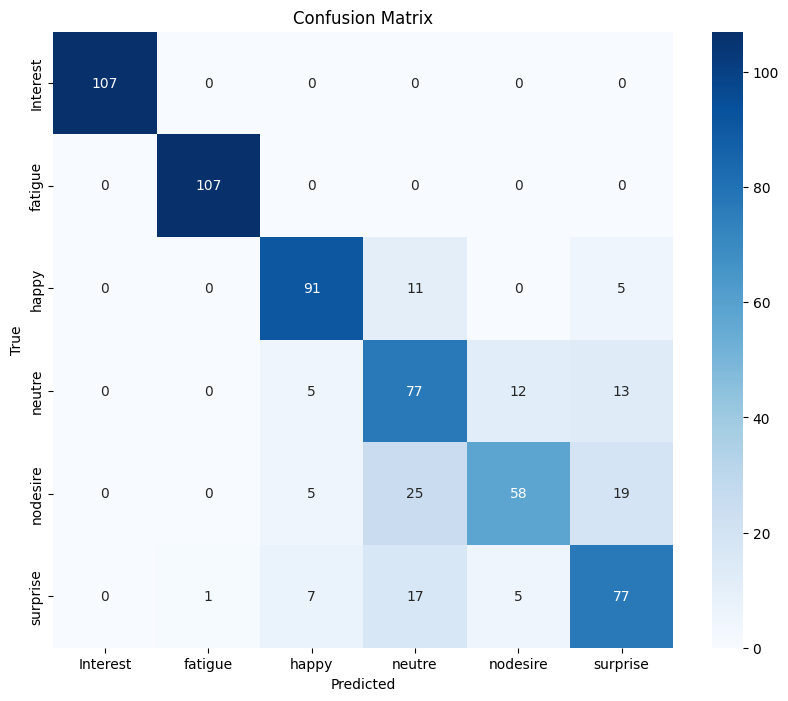

In [10]:
# Prédictions
y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

# Matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.class_indices.keys(), yticklabels=test_data.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# Open cv Test

In [12]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import time

# Charger le modèle
model = load_model('final_model_with_best_accuraccy.h5')

# Obtenir les classes
class_labels = ['happy', 'nodesire', 'neutral', 'interest', 'surprised', 'fatigue']

# Charger le classificateur de visages
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Fonction pour prédire l'émotion
def predict_emotion(face):
    # Prétraiter l'image du visage
    resized_face = cv2.resize(face, (128, 128))
    normalized_face = resized_face / 255.0
    input_data = np.expand_dims(normalized_face, axis=0)

    # Faire une prédiction
    predictions = model.predict(input_data)
    predicted_label_index = np.argmax(predictions)
    predicted_label = class_labels[predicted_label_index]
    confidence = predictions[0][predicted_label_index] * 100  # Pourcentage

    return predicted_label, confidence

# Activer la webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Erreur : Impossible d'ouvrir la caméra.")
    exit()

# Calcul des FPS
fps = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Erreur : Impossible de lire la vidéo.")
        break

    # Convertir l'image en niveaux de gris pour la détection de visages
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Détection des visages
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))

    # Vérifier s'il y a des visages
    for (x, y, w, h) in faces:
        # Extraire le visage détecté
        face = frame[y:y + h, x:x + w]

        # Prévoir l'émotion pour ce visage
        emotion, confidence = predict_emotion(face)

        # Dessiner un rectangle autour du visage
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Afficher l'émotion prédite et la confiance
        text = f"{emotion}: {confidence:.2f}%"
        cv2.putText(frame, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Calculer et afficher les FPS
    fps += 1
    elapsed_time = time.time() - start_time
    if elapsed_time > 1:
        cv2.putText(frame, f"FPS: {fps}", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        fps = 0
        start_time = time.time()

    # Afficher le flux vidéo avec les annotations
    cv2.imshow('Emotion Detection', frame)

    # Appuyer sur 'q' pour quitter
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━